## 1. Dataset Selection
*Source: Kaggle — ffatty/plain-text-wikipedia-simpleenglish*

Simple English Wikipedia dataset was chosen as it provides a large, diverse text corpus of 249,396 articles. The dataset uses articles from simple english wikipedia which uses shorter sentences with common vocabulary making it well-suited for a bigram model. Articles span across various categories providing high diversity and large number of unique bigram pairs.

### Pre-processing steps
- Combined text file was loaded as a single string using Python's file reader.
- Text was converted into lowercase before tokenization.
- nltk's "word_tokenize" was used to split the text into tokens.

In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ffatty/plain-text-wikipedia-simpleenglish")

print("Path to dataset files:", path)

Path to dataset files: /home/sraja/.cache/kagglehub/datasets/ffatty/plain-text-wikipedia-simpleenglish/versions/2


In [22]:
import nltk
import numpy as np
from nltk import word_tokenize
from collections import defaultdict, Counter
import csv
import time

In [23]:
#load txt file from the dataset path
with open(path + "/AllCombined.txt", "r") as f:
    long_txt = f.read()

In [24]:
#Print the first 500 characters of the text
print(long_txt[:500])


April

April (Apr.) is the fourth month of the year in the Julian and Gregorian calendars, and comes between March and May. It is one of four months to have 30 days.

April always begins on the same day of the week as July, and additionally, January in leap years. April always ends on the same day of the week as December.

April comes between March and May, making it the fourth month of the year. It also comes first in the year out of the four months that have 30 days, as June, September and No


## 2. Training the Bigram Model
- Unigram probabilities were computed using 'FreqDist' and bigram probabilities are computed using 'bigrams' from nltk's library.
- Model uses a mixture of unigram and bigram possibilities with three values of r evaluated (0.7, 0.5 and 0.3)
- The initial approach to applying mixture model involved iterating over all vocabulary words produces O(V^2) complexity and was computationally infeasible. To resolve this model iterates over the words that were actually observed after the word1.

In [25]:
start_time = time.time()

# Tokenize the text
tokens = word_tokenize(long_txt.lower())

## UNIGRAM
# Build a frequency distribution of the tokens
freq_dist = nltk.FreqDist(tokens)
# Normalize the frequencies to get probabilities
total_frequency = sum(freq_dist.values())
probabilities = {word: freq/total_frequency for word, freq in freq_dist.items()}

# BIGRAM
# Compute the bigrams
bigrams = list(nltk.bigrams(tokens))
total_bigrams = float(len(bigrams))
# Compute the frequency distribution of the bigrams
bigram_freq = nltk.FreqDist(bigrams)
bi_model = defaultdict(Counter)

# Populate the sparse model with conditional bigram probabilities P(w2|w1)
with open('bigram_probabilities.csv', 'w') as f:
    #Training time
    writer = csv.writer(f)
    # Loop over unique combinations, not the full text
    for (word1, word2), count in bigram_freq.items():
        bi_model[word1][word2] = count / freq_dist[word1]
        writer.writerow([word1, word2, bi_model[word1][word2]])
end_time = time.time()
print(f"Bigram model generated! -> Training time: {end_time - start_time:.2f} seconds")

Bigram model generated! -> Training time: 124.84 seconds


In [26]:
#Total bigrams:  {total_bigrams}
print(f"Total bigrams: {total_bigrams}")

Total bigrams: 34748901.0


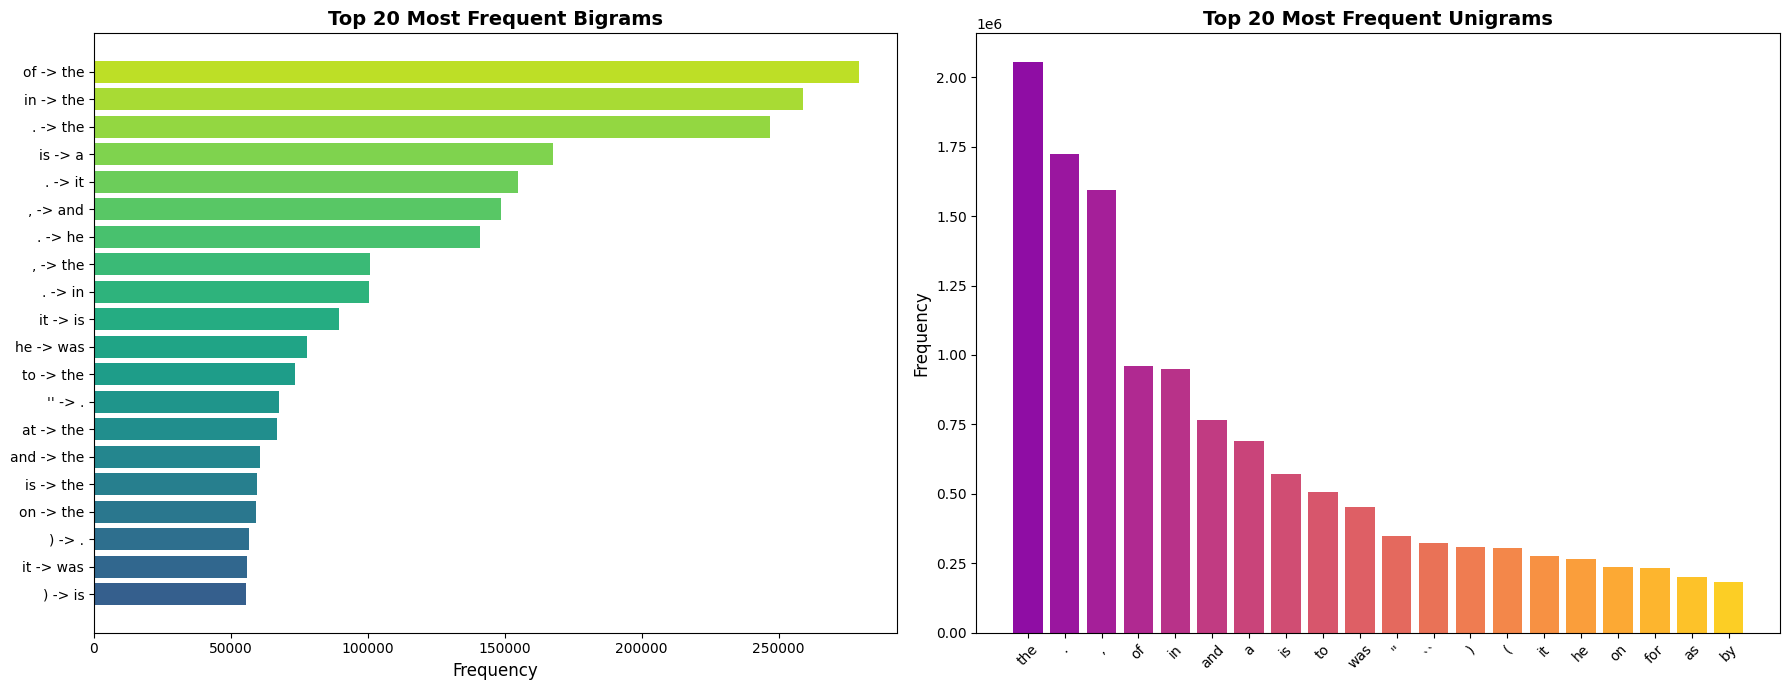

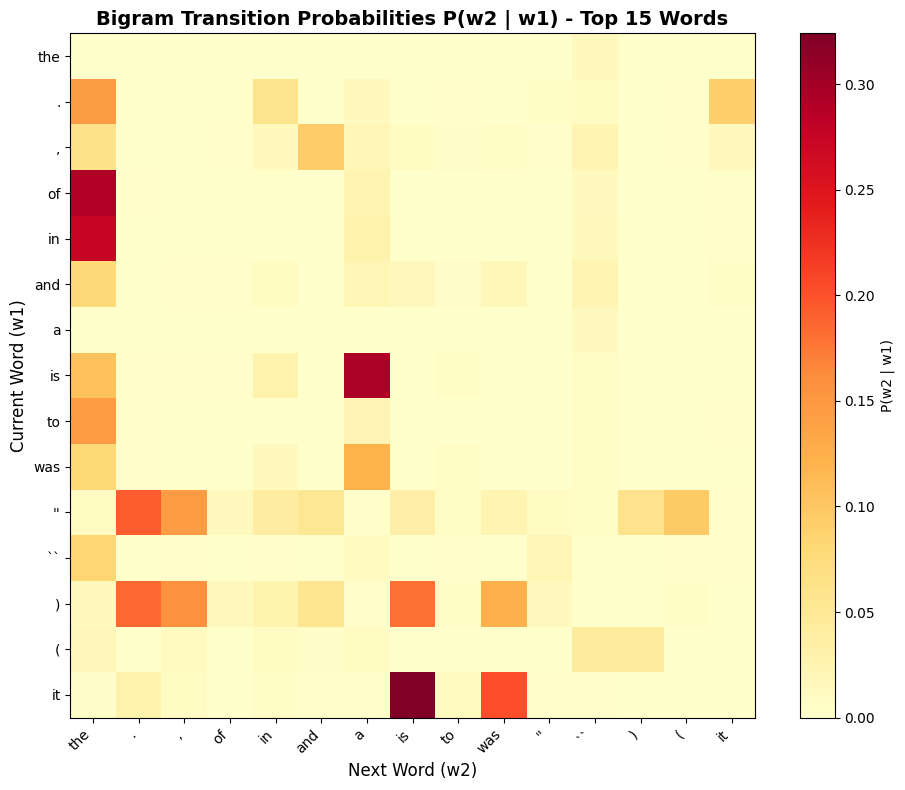

In [27]:
# Visualize the bigrams from training texts
import matplotlib.pyplot as plt

# Top 20 Most Frequent Bigrams
top_bigrams = bigram_freq.most_common(20)
bigram_labels = [f"{w1} -> {w2}" for (w1, w2), _ in top_bigrams]
bigram_counts = [count for _, count in top_bigrams]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot: Top bigrams bar chart
axes[0].barh(bigram_labels[::-1], bigram_counts[::-1], color=plt.cm.viridis(np.linspace(0.3, 0.9, 20)))
axes[0].set_xlabel("Frequency", fontsize=12)
axes[0].set_title("Top 20 Most Frequent Bigrams", fontsize=14, fontweight="bold")
axes[0].tick_params(axis="y", labelsize=10)

# Top 20 Most Frequent Unigrams 
top_unigrams = freq_dist.most_common(20)
unigram_labels = [w for w, _ in top_unigrams]
unigram_counts = [c for _, c in top_unigrams]

axes[1].bar(unigram_labels, unigram_counts, color=plt.cm.plasma(np.linspace(0.3, 0.9, 20)))
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Top 20 Most Frequent Unigrams", fontsize=14, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=10)

plt.tight_layout()
plt.show()

# Bigram Heatmap for Top 15 Words
top_words = [w for w, _ in freq_dist.most_common(15)]
heatmap_data = np.zeros((15, 15))
for i, w1 in enumerate(top_words):
    for j, w2 in enumerate(top_words):
        if w2 in bi_model[w1]:
            heatmap_data[i][j] = bi_model[w1][w2]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data, cmap="YlOrRd")
ax.set_xticks(range(15))
ax.set_yticks(range(15))
ax.set_xticklabels(top_words, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(top_words, fontsize=10)
ax.set_title("Bigram Transition Probabilities P(w2 | w1) - Top 15 Words", fontsize=14, fontweight="bold")
ax.set_xlabel("Next Word (w2)", fontsize=12)
ax.set_ylabel("Current Word (w1)", fontsize=12)
plt.colorbar(im, ax=ax, label="P(w2 | w1)")
plt.tight_layout()
plt.show()

In [28]:
#Top 10 most probable bigrams and unigrams for a given word
word = "the"
print(f"Top 10 bigrams for '{word}':")
for word2, prob in bi_model[word].most_common(10):
    print(f"{word} {word2}: {prob:.4f}")

print(f"\nTop 10 unigrams for '{word}':")
for word, prob in sorted(
    probabilities.items(), 
    key=lambda item: item[1], 
    reverse=True)[:10]:
    print(f"{word}: {prob:.4f}")

Top 10 bigrams for 'the':
the first: 0.0181
the united: 0.0173
the ``: 0.0150
the same: 0.0083
the world: 0.0078
the city: 0.0075
the age: 0.0074
the most: 0.0071
the second: 0.0055
the national: 0.0054

Top 10 unigrams for 'the':
the: 0.0591
.: 0.0496
,: 0.0459
of: 0.0277
in: 0.0273
and: 0.0220
a: 0.0199
is: 0.0164
to: 0.0146
was: 0.0130


In [29]:
def sample_bi_gram_mixture(word1, r=0.7):
    if word1 in bi_model and len(bi_model[word1]) > 0:
        bigram_probs = bi_model[word1]
        bigram_sum = sum(bigram_probs.values())
        # Only iterate over words actually seen after word1 (sparse)
        combined = {
            w: (p / bigram_sum) * r + probabilities[w] * (1 - r)
            for w, p in bigram_probs.items()
        }
    else:
        combined = probabilities  # fallback to unigram

    total = sum(combined.values())
    words = list(combined.keys())
    probs = [p / total for p in combined.values()]
    return np.random.choice(words, p=probs)

In [30]:
# Repeat word sample to generate a sequence of words
import re
import string
    
# Repeat word sampling from bi-grams to generate a sentence
def generate_bigram_sentence(start, r=0.7):
    word = start
    while word not in ['.', '!', '?']:
        if re.fullmatch(r'[' + re.escape(string.punctuation) + r']*$', word):
            print(f"{word}", end="")
        else:
            print(f" {word}", end="")
        word = sample_bi_gram_mixture(word, r)
    print(word)

## 3. Testing the model
The function 'generate_bigram_sentence' is used to generate sentences for four different starting words, **"the"**, **"to"** , **"was"** and **"kenopsia"**.

- **r = 0.7** provides locally plausible word pairs (eg "why they", "years old" etc.) but sentences start to drift across multiple unrelated topics as the sentence grows longer. The high bigram weight helps to keep individual transitions seem natural, with any long range context.

- **r = 0.5** provides shorter sentences, but we can observe the word transitions becoming more erratic. The balanced wight means the sentences change transition frequently.

- **r = 0.3** provides shortest sentences. With weight preferring unigram probabilities means common words like 'the', 'and' are more likely to be sample at each step.

Generated text is largely incoherent, which is expected and reveals the fundamental limitations of a bigram language model. In addition the dataset choice also causes erratic transitions in the generated sentences between multiple topics as the training articles span across various categories. 


In [78]:
generate_bigram_sentence("the", r=0.7)

 the region are a word for, to way that month of muslim turco-mongol empires popularized by her level.


In [81]:
generate_bigram_sentence("to", r=0.7)

 to strive to mouth is in terrestrial kangaroos in all not, the name as first gathered their songs- because his ideas and well-known bestseller list( pronounced: johnny in his.


In [86]:
generate_bigram_sentence("was", r=0.7)

 was one a commune of, where there are easily than for the tate online consultation with white edges of soubise and scales and the be complicated organisms, beating aragua aragua in public are the at the possible states.


In [109]:
generate_bigram_sentence("kenopsia", r=0.7)

 kenopsia oh no help of the 17th in the snowflakes and drink and through bargain away.


In [135]:
generate_bigram_sentence("the", r=0.5)

 the god it most cases are a computer in greenville, nagachika occupied a frog.


In [133]:
generate_bigram_sentence("to", r=0.5)

 to their foreign people stated goal.


In [126]:
generate_bigram_sentence("was", r=0.5)

 was a 1 to the may 16, county seat is for his career in, which made by irish ancestry of carter welker, the fire to be tuned mass on( role of nitrogen fixation, the a district.


In [121]:
generate_bigram_sentence("kenopsia", r=0.5)

 kenopsia other movies followed known globular lightning are.


In [120]:
generate_bigram_sentence("the", r=0.3)

 the executive yuan,.


In [117]:
generate_bigram_sentence("to", r=0.3)

 to and birds making, to be concentration of three years.


In [115]:
generate_bigram_sentence("was", r=0.3)

 was, had changed of marine and camps, and.


In [137]:
generate_bigram_sentence("kenopsia", r=0.3)

 kenopsia very an a good in,.


## 4. Documentation of the Process

**Bigram model**

A Bigram model is a first order markov chain, with the assumption that probability of next word depends only on the the current word i.e. Each unique word is a state and each bigram transition P(w2/w1) is the probability that state will transition form word w1 to w2. This is equivalent to to a state-space search, each state has defined transitions to neighboring states and an algorithm deciding which path to follow. The key difference is that search algorithms like best first use heuristics to minimize cost towards a goal state while the bigram model samples randomly.

Bigram model with a vocabulary size of V has V^2 parameters. In case of a data sparsity most word pairs never appear together, leaving the majority of the transition table empty. This model addresses this by transitioning to unigram probabilities ensuring every word has a non-zero probability to appear regardless of the current word.

**Prompt/Input**

Sentences are generated for four different starting words, **"the"**, **"to"** , **"was"** and **"kenopsia"**. These were selected based on the occurrence in dataset, words the, to and was appear frequently in the dataset whereas the word kenopsia is uncommon word. The choice of these words mean the sentences are more coherent with the common words which is expected as the model is able learn effectively using more combinations.

**Output**

The model consistently generates grammatically broken sentences. At r=0.7 the model is weighted more towards bigram probabilities and generates longer but topically scattered sentences. At r=0.3 sentences are short and terminate quickly due to high punctuation probability with unigram model weighted.

### 5.Analysis and Discussion

**Potential and Limitations**

Bigram models are effective for tasks where local word coherence is sufficient. Next-word autocompletion for domains like message autosuggest in phones, command-line suggestions work well with bigram models as it is able to perform basic text analysis that particularly reflect the training data style.

However, the bigram model has architectural limitations. The model discard long range context as the next word depends only on the current word, which means the sentences generated by such a model can not maintain the topic, enforce grammatical correctness or produce meaningful long sentences.
In addition to this bigram models are biased towards the style inherited from training data. If the training articles over-represent certain topics the generate text reflects those biases. Scaling bigram models also increases computational overhead as the required parameters for the n-gram models increases.

**Suggested Improvements**
- Higher order n-grams

Exceeding the context to higher order of preceding words improved the coherence by capturing more patterns with increased memory usage.

- Neural language models

More advanced models like Recurrent neural networks (RNNs), LSTMs and transformer-based models (BERT, GPT) overcome the limitation of n-gram model architecture by encoding the long context sentences into dense vector representations and is able to produce grammatically coherent sentences.

- Domain focused dataset

Using a dataset more focussed on a single-domain (a bunch of commonly use cli commands) would significantly improve the bigram coherence.

- Sophisticated Pre-processing

Using NLP text pre-processing techniques like Part-of-speech (POS) tagging can help assign grammatical categories - such as noun, verb adjective or adverb to each word.

- Kneser-Ney smoothing 

An alternative approach to the mixture model, Kneser-Ney smoothing improves the probability estimates for rare and unseen words by considering context diversity rather than raw frequency.



#### References
1. N-gram Language Models | https://web.stanford.edu/~jurafsky/slp3/3.pdf
2. Kneser–Ney smoothing | https://en.wikipedia.org/wiki/Kneser%E2%80%93Ney_smoothing
3. Part-of-speech tagging | https://en.wikipedia.org/wiki/Part-of-speech_tagging